In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from multidim_visualization import HighDimVisualizer, HAS_UMAP

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

In [2]:
data_path = Path("data.csv")
df = pd.read_csv(data_path)
df = df.dropna(axis=1, how="all")
print(df.shape)
display(df.head())

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
})
display(summary)
display(df["diagnosis"].value_counts().rename("count").to_frame())

,dtype,missing,unique
id,int64,0,569
diagnosis,object,0,2
radius_mean,float64,0,456
texture_mean,float64,0,479
perimeter_mean,float64,0,522
area_mean,float64,0,539
smoothness_mean,float64,0,474
compactness_mean,float64,0,537
concavity_mean,float64,0,537
concave points_mean,float64,0,542


,count
diagnosis,
B,357
M,212


In [4]:
target = df["diagnosis"].copy()
target_codes = target.map({"B": 0, "M": 1}).to_numpy()
features_df = df.drop(columns=["id", "diagnosis"])
feature_names = features_df.columns.tolist()
X_raw = features_df.to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(X_raw.shape)
print(np.round(X_scaled.mean(axis=0)[:5], 6))
print(np.round(X_scaled.std(axis=0)[:5], 6))

(569, 30)
[-0.  0. -0. -0. -0.]
[1. 1. 1. 1. 1.]


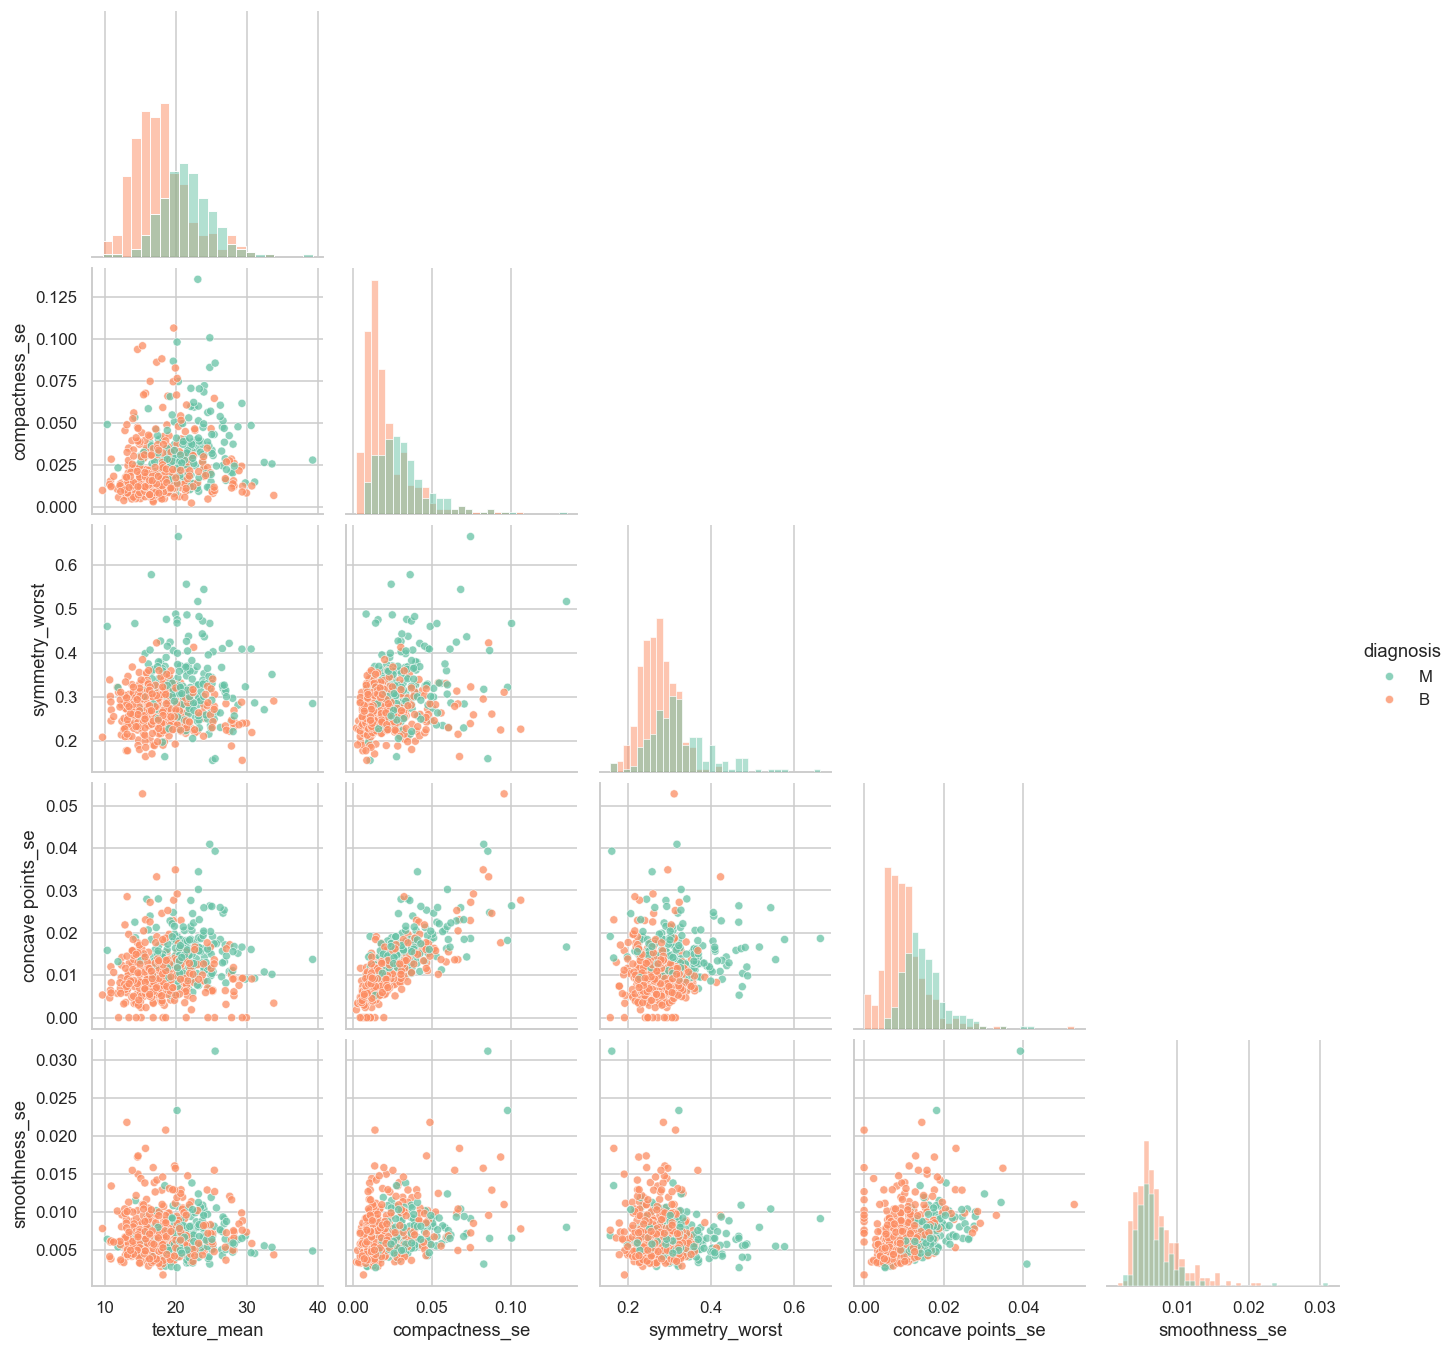

In [5]:
variance = pd.Series(X_scaled.var(axis=0), index=feature_names).sort_values(ascending=False)
selected_features = variance.head(5).index.tolist()
pair_df = df[selected_features + ["diagnosis"]].copy()
sns.pairplot(pair_df, hue="diagnosis", diag_kind="hist", corner=True, plot_kws={"alpha": 0.75, "s": 28})
plt.show()

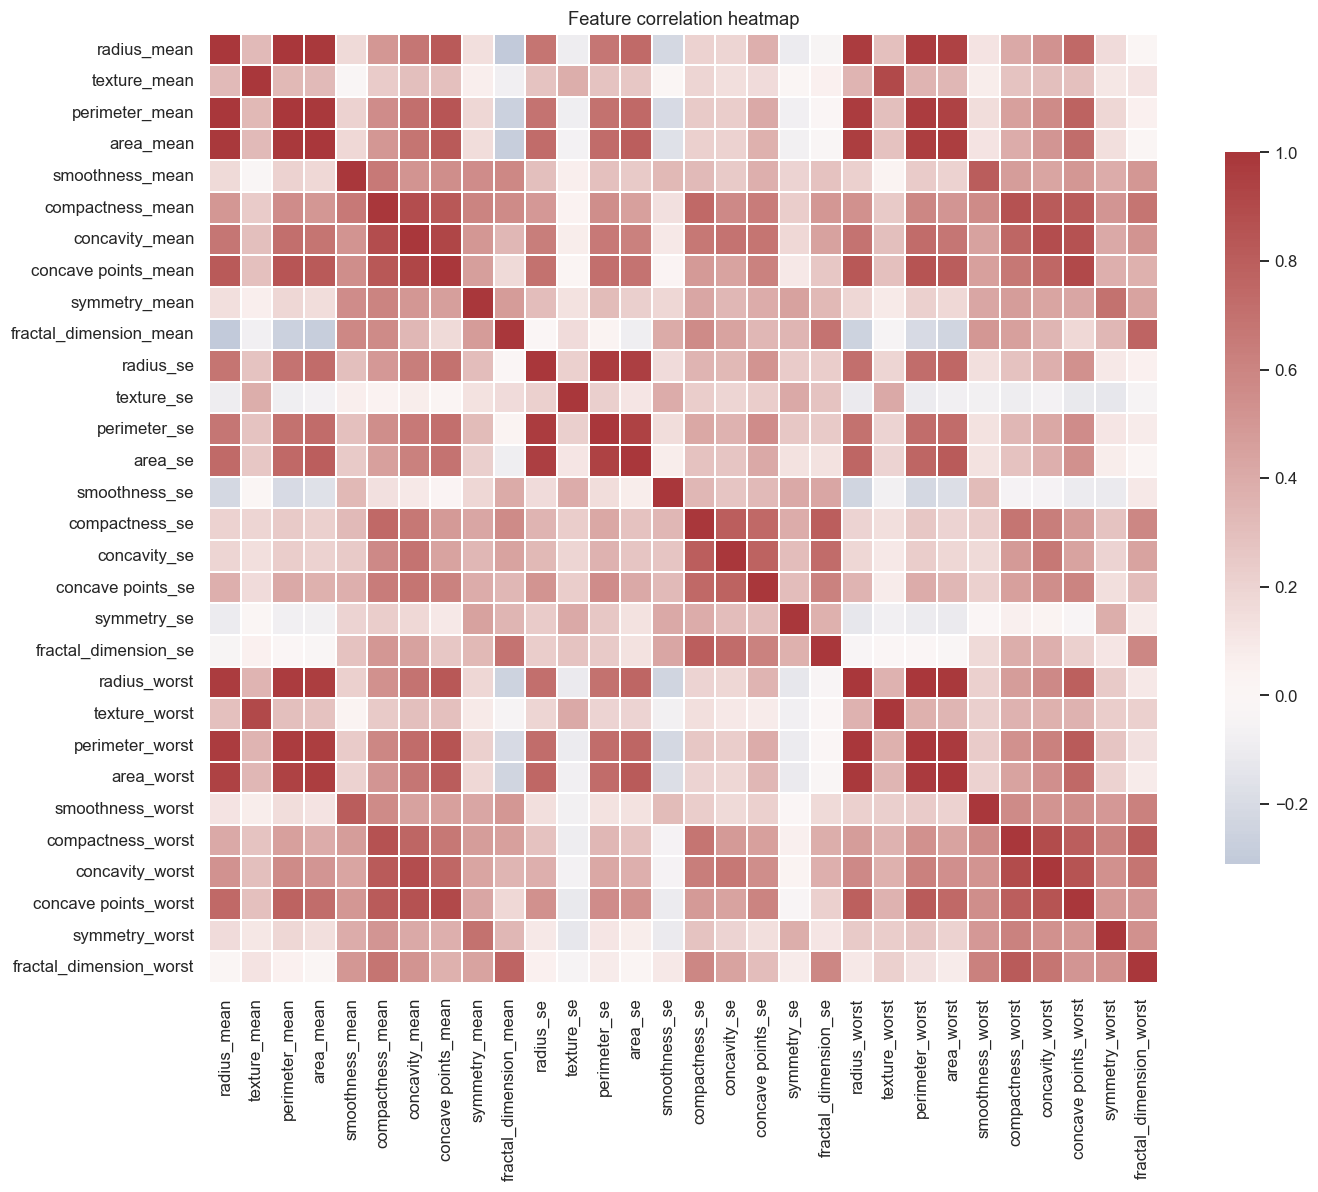

In [6]:
corr = features_df.corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.2, cbar_kws={"shrink": 0.75})
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

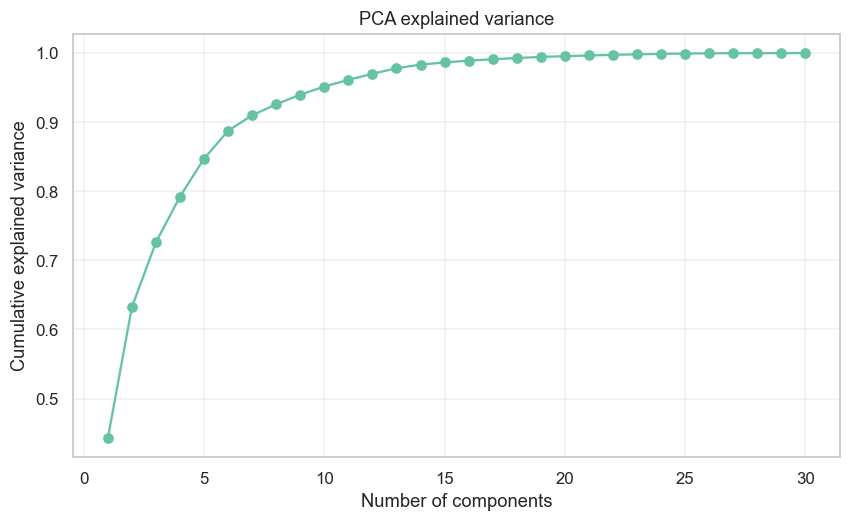

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881]


In [7]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.grid(alpha=0.3)
plt.show()
print(explained[:10])

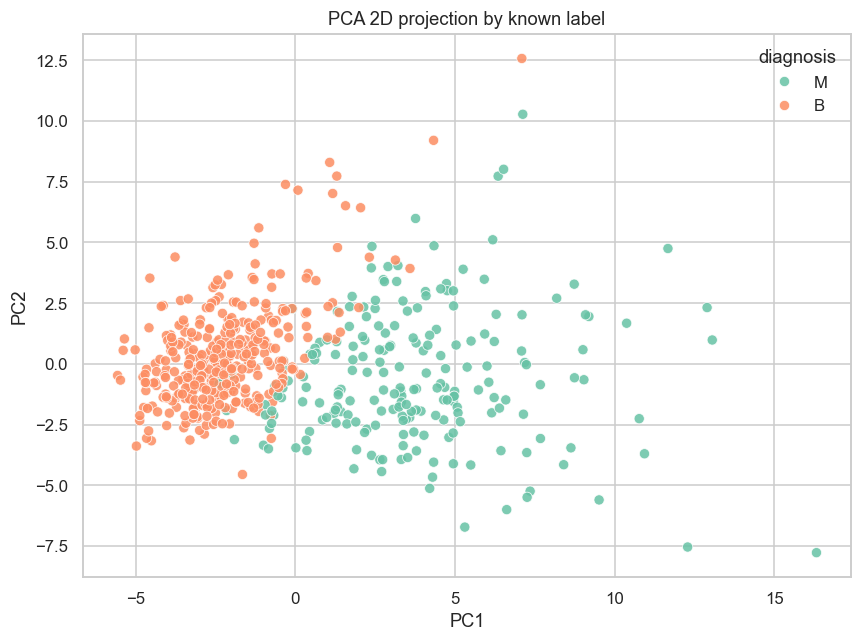

[0.44272026 0.18971182]


In [8]:
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)
pca_plot_df = pd.DataFrame({"PC1": X_pca_2[:, 0], "PC2": X_pca_2[:, 1], "diagnosis": target})
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", hue="diagnosis", alpha=0.85, s=45)
plt.title("PCA 2D projection by known label")
plt.tight_layout()
plt.show()
print(pca_2.explained_variance_ratio_)

In [9]:
pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)
pca_3d_df = pd.DataFrame({"PC1": X_pca_3[:, 0], "PC2": X_pca_3[:, 1], "PC3": X_pca_3[:, 2], "diagnosis": target})
fig = px.scatter_3d(pca_3d_df, x="PC1", y="PC2", z="PC3", color="diagnosis", title="PCA 3D projection by known label", opacity=0.82)
fig.write_html("pca_3d_known_labels.html")
fig.show()
print(pca_3.explained_variance_ratio_)

[0.44272026 0.18971182 0.09393163]


In [10]:
def cluster_metrics(X, labels, known_labels):
    unique_labels = set(labels)
    cluster_count = len([label for label in unique_labels if label != -1])
    result = {
        "clusters": cluster_count,
        "noise": int(np.sum(labels == -1)),
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
        "adjusted_rand": adjusted_rand_score(known_labels, labels)
    }
    if len(unique_labels) > 1 and len(unique_labels) < len(labels):
        result["silhouette"] = silhouette_score(X, labels)
        result["calinski_harabasz"] = calinski_harabasz_score(X, labels)
        result["davies_bouldin"] = davies_bouldin_score(X, labels)
    return result

models = {
    "KMeans": KMeans(n_clusters=2, random_state=42, n_init=20),
    "Agglomerative": AgglomerativeClustering(n_clusters=2),
    "DBSCAN": DBSCAN(eps=2.4, min_samples=8)
}
cluster_labels = {}
rows = []
for name, model in models.items():
    labels = model.fit_predict(X_scaled)
    cluster_labels[name] = labels
    row = {"method": name}
    row.update(cluster_metrics(X_scaled, labels, target_codes))
    rows.append(row)
metrics_df = pd.DataFrame(rows).set_index("method")
display(metrics_df)

,clusters,noise,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand
method,,,,,,
KMeans,2,0,0.344974,267.696404,1.312320,0.670721
Agglomerative,2,0,0.339385,248.628841,1.369964,0.575041
DBSCAN,2,277,0.009089,53.713521,1.940024,0.207323


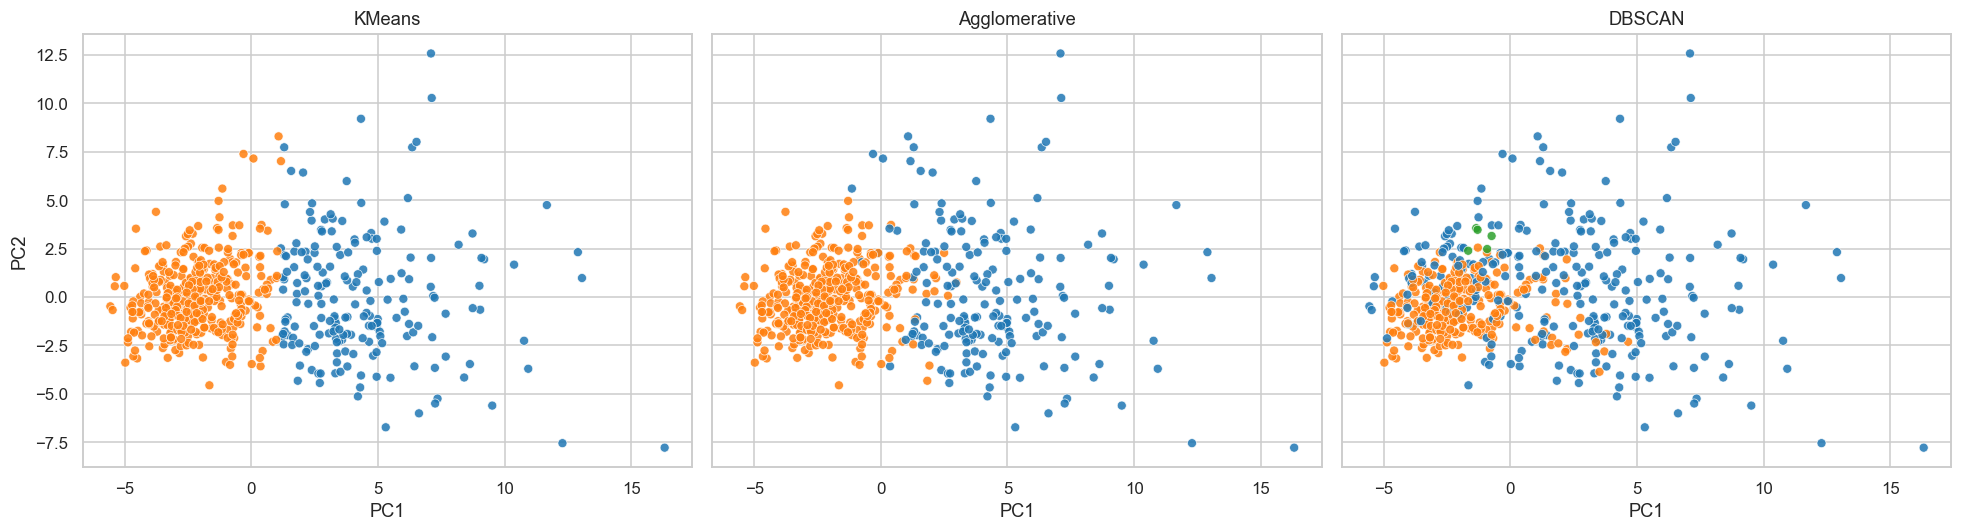

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, cluster_labels.items()):
    sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=labels, palette="tab10", ax=ax, s=35, alpha=0.85, legend=False)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

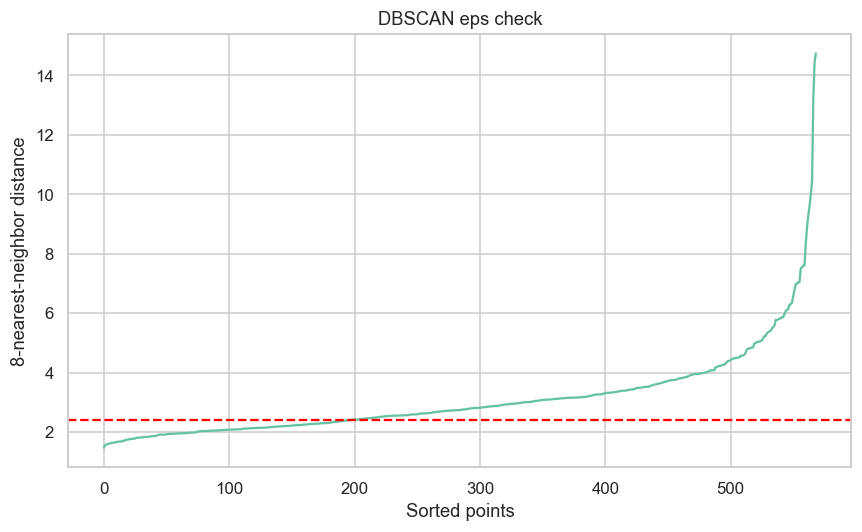

In [12]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.axhline(2.4, color="red", linestyle="--")
plt.xlabel("Sorted points")
plt.ylabel("8-nearest-neighbor distance")
plt.title("DBSCAN eps check")
plt.tight_layout()
plt.show()

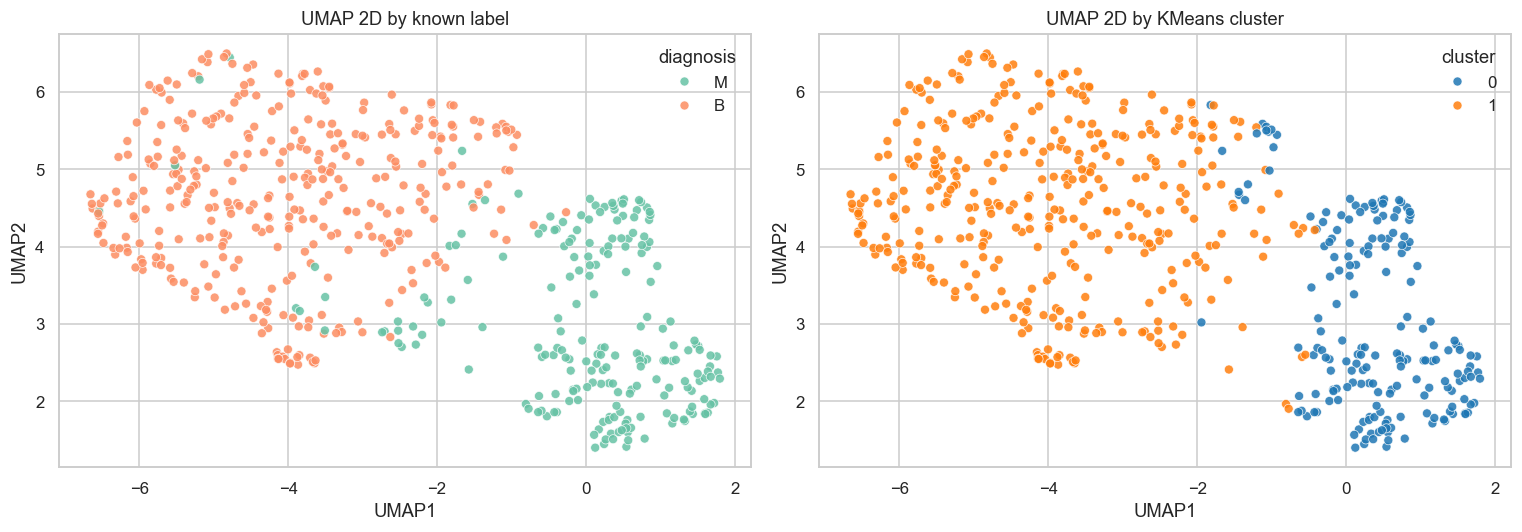

In [13]:
if HAS_UMAP:
    import umap
    reducer_2 = umap.UMAP(n_components=2, n_neighbors=25, min_dist=0.08, random_state=42)
    X_umap_2 = reducer_2.fit_transform(X_scaled)
    umap_df = pd.DataFrame({"UMAP1": X_umap_2[:, 0], "UMAP2": X_umap_2[:, 1], "diagnosis": target, "cluster": cluster_labels["KMeans"].astype(str)})
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="diagnosis", ax=axes[0], s=35, alpha=0.85)
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="cluster", ax=axes[1], s=35, alpha=0.85, palette="tab10")
    axes[0].set_title("UMAP 2D by known label")
    axes[1].set_title("UMAP 2D by KMeans cluster")
    plt.tight_layout()
    plt.show()
else:
    print("umap-learn is not installed")

In [14]:
if HAS_UMAP:
    reducer_3 = umap.UMAP(n_components=3, n_neighbors=25, min_dist=0.08, random_state=42)
    X_umap_3 = reducer_3.fit_transform(X_scaled)
    umap_3d_df = pd.DataFrame({"UMAP1": X_umap_3[:, 0], "UMAP2": X_umap_3[:, 1], "UMAP3": X_umap_3[:, 2], "diagnosis": target, "cluster": cluster_labels["KMeans"].astype(str)})
    fig = px.scatter_3d(umap_3d_df, x="UMAP1", y="UMAP2", z="UMAP3", color="cluster", symbol="diagnosis", title="UMAP 3D projection by KMeans cluster", opacity=0.82)
    fig.write_html("umap_3d_kmeans.html")
    fig.show()
else:
    print("umap-learn is not installed")

,clusters,noise,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand
0,2,0,0.343382,267.691716,1.32051,0.653625


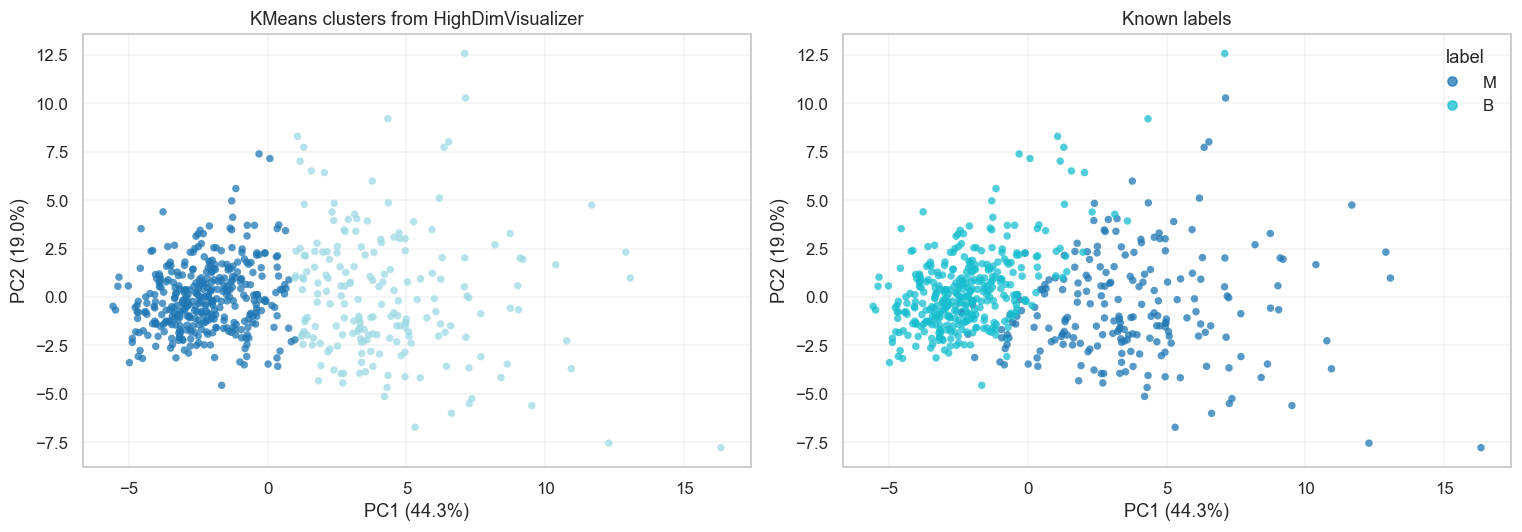

In [15]:
visualizer = HighDimVisualizer(random_state=42)
prepared_X, prepared_target, prepared_names = visualizer.prepare_dataset(df, target="diagnosis", drop_columns=["id"])
labels, model = visualizer.cluster_dataset(prepared_X, method="kmeans", n_clusters=2)
display(visualizer.evaluate_cluster_labels(prepared_X, labels, prepared_target))
visualizer.plot_cluster_projection(prepared_X, labels, title="KMeans clusters from HighDimVisualizer", target=prepared_target)
fig, X_class_pca_3, class_pca_3 = visualizer.plot_interactive_3d_clusters(prepared_X, labels, output_file="interactive_3d_plot.html", target=prepared_target, title="KMeans clusters from HighDimVisualizer")

In [16]:
print("Rows:", df.shape[0])
print("Numeric features:", len(feature_names))
print("Best adjusted rand:", metrics_df["adjusted_rand"].max())
print("Files created: pca_3d_known_labels.html, interactive_3d_plot.html")

Rows: 569
Numeric features: 30
Best adjusted rand: 0.6707206476880808
Files created: pca_3d_known_labels.html, interactive_3d_plot.html
